In [1]:
# STEP 1: Personal parameters
print("STARTING STEP 1: Personal parameters")
# DATA 266 - Homework 2 personal parameters
SID4 = 6441
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print({
    "SID4": SID4, "SEED": SEED, "SLICE": SLICE,
    "HP_ID": HP_ID, "CLS_A": CLS_A, "CLS_B": CLS_B,
})

print("STEP 1: PASS")


STARTING STEP 1: Personal parameters
{'SID4': 6441, 'SEED': 6441, 'SLICE': 441, 'HP_ID': 3, 'CLS_A': 1, 'CLS_B': 7}
STEP 1: PASS


# Nikhil Kanaparthi
## DATA 266 - Homework 2

This notebook completes all three HW2 tasks:

1. Fine-tune Google News Word2Vec embeddings on IMDB reviews.
2. Build an explicit LangChain RAG pipeline over 10 Wikipedia movie pages.
3. Compare all five requested training optimization techniques under controlled settings.

**Runtime:** Google Colab with a T4 GPU is recommended. Before running, upload
`IMDB Dataset.csv.zip` to the Colab session. The pretrained Word2Vec download is
approximately 1.6 GB and may take several minutes.


## 0. Setup


In [2]:
# STEP 2: 0. Setup
print("STARTING STEP 2: 0. Setup")
# PyTorch is already installed in Colab; reinstalling it can break the CUDA runtime.
# Gensim 4.4.0 provides wheels for newer Colab Python versions. Do not pin
# SciPy 1.12.0 because pip may try and fail to compile it from source.
%pip install -q --upgrade --only-binary=:all: "gensim==4.4.0"
%pip install -q scikit-learn matplotlib pandas numpy tabulate
%pip install -q "requests==2.32.4" "langchain-community==0.3.27" "langchain-huggingface==0.3.1" "langchain-text-splitters==0.3.9" faiss-cpu wikipedia sentence-transformers transformers accelerate

print("STEP 2: PASS")


STARTING STEP 2: 0. Setup
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.4.3 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
langgraph 1.2.11 r

In [3]:
# STEP 3: 0. Setup
print("STARTING STEP 3: 0. Setup")
import gc
import html
import json
import os
import random
import re
import time
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore", category=FutureWarning)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("hw2_outputs")
MODEL_DIR = Path("models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

RUN_LOG_LINES = []

def log(message):
    timestamp = datetime.now(timezone.utc).isoformat()
    line = f"[{timestamp}] {message}"
    RUN_LOG_LINES.append(line)
    print(line)

log(f"Started HW2 on device={DEVICE}; SID4={SID4}; SEED={SEED}")
if DEVICE.type != "cuda":
    print("WARNING: Select Runtime > Change runtime type > T4 GPU before the final run.")

print("STEP 3: PASS")


STARTING STEP 3: 0. Setup
[2026-09-08T10:01:02.932679+00:00] Started HW2 on device=cuda; SID4=6441; SEED=6441
STEP 3: PASS


---
# 1. Embedding-based transfer learning

Word2Vec represents each word as a dense vector learned from neighboring words.
Cosine similarity measures the angle between two vectors; values nearer 1 indicate
more similar directions. Transfer learning begins with the Google News vectors and
continues training them on movie-review language from IMDB.


### 1.1 Load and validate the IMDB dataset


In [4]:
# STEP 4: 1.1 Load and validate the IMDB dataset
print("STARTING STEP 4: 1.1 Load and validate the IMDB dataset")
candidates = [
    Path("IMDB Dataset.csv.zip"),
    Path("/content/IMDB Dataset.csv.zip"),
    Path("IMDB Dataset.csv"),
    Path("/content/IMDB Dataset.csv"),
]
dataset_path = next((path for path in candidates if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Upload 'IMDB Dataset.csv.zip' to Colab, then run this cell again."
    )

imdb_df = pd.read_csv(dataset_path, compression="zip" if dataset_path.suffix == ".zip" else None)
assert {"review", "sentiment"}.issubset(imdb_df.columns)
assert len(imdb_df) == 50000, f"Expected 50,000 reviews; found {len(imdb_df)}"
assert imdb_df["review"].notna().all()

display(imdb_df.head(3))
display(imdb_df["sentiment"].value_counts().rename("count").to_frame())
log(f"Loaded IMDB dataset: shape={imdb_df.shape}; path={dataset_path}")

print("STEP 4: PASS")


STARTING STEP 4: 1.1 Load and validate the IMDB dataset


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


,count
sentiment,
positive,25000
negative,25000


[2026-09-08T10:01:04.605302+00:00] Loaded IMDB dataset: shape=(50000, 2); path=IMDB Dataset.csv.zip
STEP 4: PASS


### 1.2 Load Google News Word2Vec and record baseline neighbors


In [5]:
# STEP 5: 1.2 Load Google News Word2Vec and record baseline neighbors
print("STARTING STEP 5: 1.2 Load Google News Word2Vec and record baseline neighbors")
import gensim.downloader as gensim_api

TARGET_WORDS = ["cast", "score", "plot", "screen", "review"]

# Downloads about 1.6 GB on the first run.
pretrained_kv = gensim_api.load("word2vec-google-news-300")
assert all(word in pretrained_kv for word in TARGET_WORDS)

# Copy the original target vectors before any fine-tuning work.
original_target_vectors = {word: pretrained_kv[word].copy() for word in TARGET_WORDS}

def nearest_neighbor_table(keyed_vectors, words, stage, topn=3):
    rows = []
    for word in words:
        for rank, (neighbor, similarity) in enumerate(
            keyed_vectors.most_similar(word, topn=topn), start=1
        ):
            rows.append({
                "word": word,
                "stage": stage,
                "rank": rank,
                "neighbor": neighbor,
                "cosine_similarity": float(similarity),
            })
    return pd.DataFrame(rows)

neighbors_before = nearest_neighbor_table(pretrained_kv, TARGET_WORDS, "Before")
display(neighbors_before.style.format({"cosine_similarity": "{:.4f}"}))
log(f"Loaded word2vec-google-news-300: vocab={len(pretrained_kv):,}; dimensions={pretrained_kv.vector_size}")

print("STEP 5: PASS")


STARTING STEP 5: 1.2 Load Google News Word2Vec and record baseline neighbors
[==================================================] 100.0% 1662.8/1662.8MB downloaded


,word,stage,rank,neighbor,cosine_similarity
0,cast,Before,1,casts,0.7219
1,cast,Before,2,casting,0.7188
2,cast,Before,3,Cast,0.6638
3,score,Before,1,scoring,0.7197
4,score,Before,2,scores,0.6596
5,score,Before,3,scored,0.6384
6,plot,Before,1,plots,0.7625
7,plot,Before,2,Plot,0.6524
8,plot,Before,3,plotting,0.6328
9,screen,Before,1,screens,0.7729


[2026-09-08T10:06:44.372552+00:00] Loaded word2vec-google-news-300: vocab=3,000,000; dimensions=300
STEP 5: PASS


### 1.3 Fine-tune pretrained embeddings on IMDB reviews


In [6]:
# STEP 6: 1.3 Fine-tune pretrained embeddings on IMDB reviews
print("STARTING STEP 6: 1.3 Fine-tune pretrained embeddings on IMDB reviews")
from gensim.models import Word2Vec

def tokenize_review(text):
    text = html.unescape(str(text)).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z0-9']+", " ", text)
    return [token for token in text.split() if token]

# The course demo uses 10,000 reviews to keep Colab runtime manageable.
# A balanced, seeded sample makes the choice reproducible.
N_FINETUNE_REVIEWS = 10000
sampled_reviews = (
    imdb_df.groupby("sentiment", group_keys=False)
    .sample(n=N_FINETUNE_REVIEWS // 2, random_state=SEED)
    .sample(frac=1, random_state=SEED)
)
imdb_sentences = [tokenize_review(text) for text in sampled_reviews["review"]]

finetuned_model = Word2Vec(
    vector_size=pretrained_kv.vector_size,
    window=5,
    min_count=2,
    workers=1,          # one worker improves reproducibility
    sg=1,
    negative=10,
    seed=SEED,
    epochs=5,
)
finetuned_model.build_vocab(imdb_sentences)

seeded_count = 0
for word in finetuned_model.wv.index_to_key:
    if word in pretrained_kv:
        finetuned_model.wv[word] = pretrained_kv[word]
        seeded_count += 1

train_start = time.perf_counter()
finetuned_model.train(
    imdb_sentences,
    total_examples=finetuned_model.corpus_count,
    epochs=finetuned_model.epochs,
)
finetune_seconds = time.perf_counter() - train_start

checkpoint_path = MODEL_DIR / f"imdb_word2vec_finetuned_sid{SID4}.model"
finetuned_model.save(str(checkpoint_path))

assert all(word in finetuned_model.wv for word in TARGET_WORDS)
log(
    f"Fine-tuned Word2Vec on {len(imdb_sentences):,} reviews for "
    f"{finetuned_model.epochs} epochs in {finetune_seconds:.2f}s; "
    f"seeded={seeded_count:,}; checkpoint={checkpoint_path}"
)

print("STEP 6: PASS")


STARTING STEP 6: 1.3 Fine-tune pretrained embeddings on IMDB reviews
[2026-09-08T10:16:48.258238+00:00] Fine-tuned Word2Vec on 10,000 reviews for 5 epochs in 221.27s; seeded=26,458; checkpoint=models/imdb_word2vec_finetuned_sid6441.model
STEP 6: PASS


### 1.4 Before-and-after neighbor table and vector shifts


In [7]:
# STEP 7: 1.4 Before-and-after neighbor table and vector shifts
print("STARTING STEP 7: 1.4 Before-and-after neighbor table and vector shifts")
from scipy.spatial.distance import cosine

neighbors_after = nearest_neighbor_table(finetuned_model.wv, TARGET_WORDS, "After")
neighbor_comparison = (
    neighbors_before.merge(
        neighbors_after,
        on=["word", "rank"],
        suffixes=("_before", "_after"),
    )[
        [
            "word", "rank", "neighbor_before", "cosine_similarity_before",
            "neighbor_after", "cosine_similarity_after",
        ]
    ]
)
display(neighbor_comparison.style.format({
    "cosine_similarity_before": "{:.4f}",
    "cosine_similarity_after": "{:.4f}",
}))

shift_rows = []
for word in TARGET_WORDS:
    similarity = 1.0 - cosine(original_target_vectors[word], finetuned_model.wv[word])
    shift_rows.append({
        "word": word,
        "original_vs_finetuned_cosine": float(similarity),
        "shift_distance": float(1.0 - similarity),
    })

shift_df = pd.DataFrame(shift_rows).sort_values(
    "original_vs_finetuned_cosine", ascending=True
).reset_index(drop=True)
display(shift_df.style.format({
    "original_vs_finetuned_cosine": "{:.4f}",
    "shift_distance": "{:.4f}",
}))

most_shifted = shift_df.iloc[0]
least_shifted = shift_df.iloc[-1]
print(
    f"Most shifted: {most_shifted['word']} "
    f"(cosine={most_shifted['original_vs_finetuned_cosine']:.4f})"
)
print(
    f"Least shifted: {least_shifted['word']} "
    f"(cosine={least_shifted['original_vs_finetuned_cosine']:.4f})"
)
log(
    f"Embedding shifts: most={most_shifted['word']}; "
    f"least={least_shifted['word']}"
)

print("STEP 7: PASS")


STARTING STEP 7: 1.4 Before-and-after neighbor table and vector shifts


,word,rank,neighbor_before,cosine_similarity_before,neighbor_after,cosine_similarity_after
0,cast,1,casts,0.7219,casts,0.5920
1,cast,2,casting,0.7188,supporting,0.5878
2,cast,3,Cast,0.6638,casted,0.5736
3,score,1,scoring,0.7197,scoring,0.5806
4,score,2,scores,0.6596,scores,0.5803
5,score,3,scored,0.6384,scored,0.5410
6,plot,1,plots,0.7625,storyline,0.6497
7,plot,2,Plot,0.6524,plots,0.6321
8,plot,3,plotting,0.6328,story,0.6234
9,screen,1,screens,0.7729,screens,0.5892


,word,original_vs_finetuned_cosine,shift_distance
0,review,0.6186,0.3814
1,screen,0.6756,0.3244
2,score,0.6844,0.3156
3,cast,0.6855,0.3145
4,plot,0.6932,0.3068


Most shifted: review (cosine=0.6186)
Least shifted: plot (cosine=0.6932)
[2026-09-08T10:16:48.359956+00:00] Embedding shifts: most=review; least=plot
STEP 7: PASS


### 1.5 Visualize one embedding shift with t-SNE


STARTING STEP 8: 1.5 Visualize one embedding shift with t-SNE


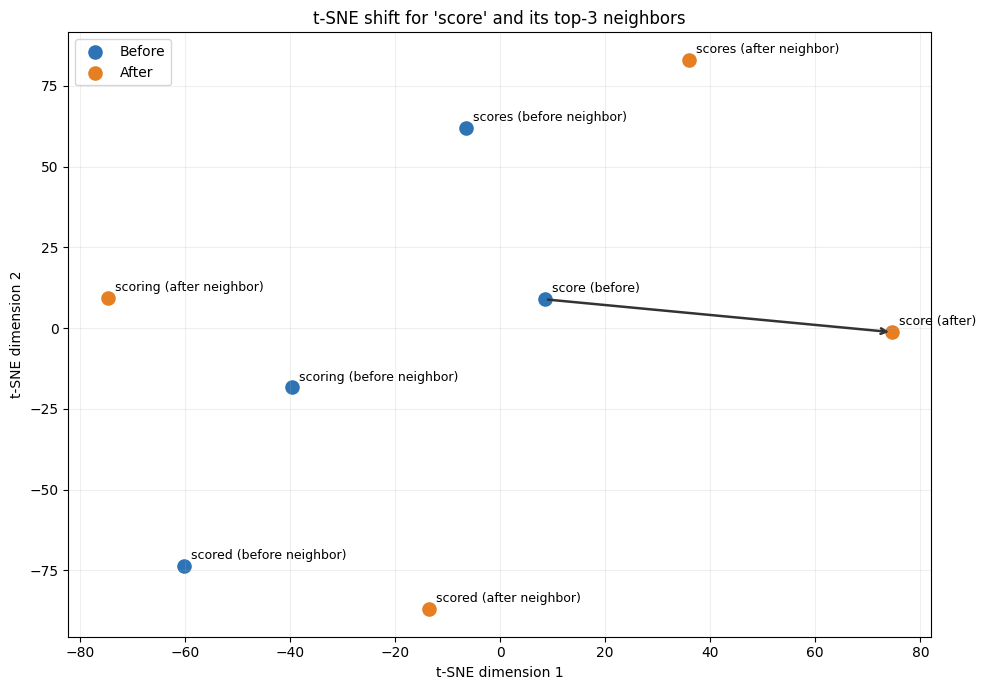

[2026-09-08T10:16:50.063345+00:00] Saved embedding visualization: hw2_outputs/embedding_shift_score.png
STEP 8: PASS


In [8]:
# STEP 8: 1.5 Visualize one embedding shift with t-SNE
print("STARTING STEP 8: 1.5 Visualize one embedding shift with t-SNE")
from sklearn.manifold import TSNE

VIZ_WORD = "score"
before_neighbor_words = neighbors_before.query("word == @VIZ_WORD")["neighbor"].tolist()
after_neighbor_words = neighbors_after.query("word == @VIZ_WORD")["neighbor"].tolist()

vectors = [original_target_vectors[VIZ_WORD], finetuned_model.wv[VIZ_WORD]]
labels = [f"{VIZ_WORD} (before)", f"{VIZ_WORD} (after)"]
groups = ["Before", "After"]

for neighbor in before_neighbor_words:
    vectors.append(pretrained_kv[neighbor])
    labels.append(f"{neighbor} (before neighbor)")
    groups.append("Before")
for neighbor in after_neighbor_words:
    vectors.append(finetuned_model.wv[neighbor])
    labels.append(f"{neighbor} (after neighbor)")
    groups.append("After")

vectors = np.asarray(vectors)
coords = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=min(5, len(vectors) - 1),
    init="pca",
    learning_rate="auto",
).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))
colors = {"Before": "#2E74B5", "After": "#E67E22"}
for group in ["Before", "After"]:
    indices = [i for i, value in enumerate(groups) if value == group]
    ax.scatter(coords[indices, 0], coords[indices, 1], s=90, label=group, color=colors[group])
for index, label in enumerate(labels):
    ax.annotate(label, coords[index], xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.annotate(
    "",
    xy=coords[1],
    xytext=coords[0],
    arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1.8},
)
ax.set_title(f"t-SNE shift for '{VIZ_WORD}' and its top-3 neighbors")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
embedding_plot_path = OUTPUT_DIR / "embedding_shift_score.png"
fig.savefig(embedding_plot_path, dpi=180, bbox_inches="tight")
plt.show()
log(f"Saved embedding visualization: {embedding_plot_path}")

print("STEP 8: PASS")


### 1.6 Final interpretation

The original-to-fine-tuned cosine similarities were **0.6186 for review**, **0.6756
for screen**, **0.6844 for score**, **0.6855 for cast**, and **0.6932 for plot**.
Because a lower cosine similarity represents a larger directional change, **review
shifted the most**, while **plot shifted the least**. The nearest-neighbor changes also
show adaptation to movie-review language. For example, plot changed from mostly
morphological neighbors (`plots`, `Plot`, `plotting`) to movie-related words
(`storyline`, `plots`, `story`), and review gained `comment` and `ebert` as neighbors.
The t-SNE plot for score provides a qualitative view of this displacement; its axes and
distances should not be interpreted as exact measurements. Overall, fine-tuning changed
the local semantic neighborhoods while preserving part of the original embedding structure.


In [9]:
# STEP 9: 1.6 Interpretation
print("STARTING STEP 9: 1.6 Interpretation")
# Release the very large Google News vectors before loading the RAG language model.
del pretrained_kv, imdb_sentences, sampled_reviews
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
log("Released Word2Vec source objects before RAG model loading")

print("STEP 9: PASS")


STARTING STEP 9: 1.6 Interpretation
[2026-09-08T10:16:50.652547+00:00] Released Word2Vec source objects before RAG model loading
STEP 9: PASS


---
# 2. Retrieval-Augmented Generation with LangChain

The pipeline is assembled from explicit components: a Wikipedia document loader,
recursive text splitter, sentence-transformer embeddings, FAISS vector store,
retriever, prompt template, and local FLAN-T5 language model. It does not use a
one-call prebuilt retrieval chain.


### 2.1 Load 10 Wikipedia movie documents


In [10]:
# STEP 10: 2.1 Load 10 Wikipedia movie documents
print("STARTING STEP 10: 2.1 Load 10 Wikipedia movie documents")
from langchain_community.document_loaders import WikipediaLoader

MOVIES = [
    "Inception",
    "The Godfather",
    "Titanic (1997 film)",
    "The Dark Knight",
    "Pulp Fiction",
    "Forrest Gump",
    "The Matrix",
    "Interstellar",
    "Parasite (2019 film)",
    "Gladiator (2000 film)",
]

documents = []
for movie in MOVIES:
    loaded = WikipediaLoader(
        query=movie,
        load_max_docs=1,
        doc_content_chars_max=200000,
    ).load()
    if not loaded:
        raise RuntimeError(f"WikipediaLoader returned no document for {movie}")
    loaded[0].metadata["requested_movie"] = movie
    documents.append(loaded[0])

document_inventory = pd.DataFrame([
    {
        "requested_movie": doc.metadata.get("requested_movie"),
        "loaded_title": doc.metadata.get("title"),
        "characters": len(doc.page_content),
        "source": doc.metadata.get("source"),
    }
    for doc in documents
])
display(document_inventory)
assert len(documents) == 10
log(f"Loaded {len(documents)} Wikipedia movie documents")

print("STEP 10: PASS")


STARTING STEP 10: 2.1 Load 10 Wikipedia movie documents


,requested_movie,loaded_title,characters,source
0,Inception,Inception,52476,https://en.wikipedia.org/wiki/Inception
1,The Godfather,The Godfather,55086,https://en.wikipedia.org/wiki/The_Godfather
2,Titanic (1997 film),Titanic (1997 film),89379,https://en.wikipedia.org/wiki/Titanic_(1997_film)
3,The Dark Knight,The Dark Knight,73031,https://en.wikipedia.org/wiki/The_Dark_Knight
4,Pulp Fiction,Pulp Fiction,81910,https://en.wikipedia.org/wiki/Pulp_Fiction
5,Forrest Gump,Forrest Gump,36744,https://en.wikipedia.org/wiki/Forrest_Gump
6,The Matrix,The Matrix,61192,https://en.wikipedia.org/wiki/The_Matrix
7,Interstellar,Interstellar (film),45296,https://en.wikipedia.org/wiki/Interstellar_(film)
8,Parasite (2019 film),Parasite (2019 film),39456,https://en.wikipedia.org/wiki/Parasite_(2019_f...
9,Gladiator (2000 film),Gladiator (2000 film),28043,https://en.wikipedia.org/wiki/Gladiator_(2000_...


[2026-09-08T10:17:02.547070+00:00] Loaded 10 Wikipedia movie documents
STEP 10: PASS


### 2.2 Split documents into 500-character chunks with 50-character overlap


In [11]:
# STEP 11: 2.2 Split documents into 500-character chunks with 50-character overlap
print("STARTING STEP 11: 2.2 Split documents into 500-character chunks with 50-character overlap")
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_documents(source_documents, chunk_size=500, chunk_overlap=50):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    return splitter.split_documents(source_documents)

chunks_500_50 = split_documents(documents, chunk_size=500, chunk_overlap=50)
chunk_lengths = np.array([len(chunk.page_content) for chunk in chunks_500_50])
print(f"Chunks: {len(chunks_500_50)}")
print(
    f"Character lengths: min={chunk_lengths.min()}, "
    f"median={np.median(chunk_lengths):.0f}, max={chunk_lengths.max()}"
)
assert chunk_lengths.max() <= 500
log(f"Created {len(chunks_500_50)} chunks using size=500, overlap=50")

print("STEP 11: PASS")


STARTING STEP 11: 2.2 Split documents into 500-character chunks with 50-character overlap
Chunks: 1764
Character lengths: min=10, median=366, max=500
[2026-09-08T10:17:02.591220+00:00] Created 1764 chunks using size=500, overlap=50
STEP 11: PASS


### 2.3 Embed chunks and build a FAISS vector store


In [12]:
# STEP 12: 2.3 Embed chunks and build a FAISS vector store
print("STARTING STEP 12: 2.3 Embed chunks and build a FAISS vector store")
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": str(DEVICE)},
    encode_kwargs={"normalize_embeddings": True},
)

def build_vector_store(source_chunks):
    return FAISS.from_documents(source_chunks, embedding_model)

vectorstore_500_50 = build_vector_store(chunks_500_50)
faiss_path = OUTPUT_DIR / "faiss_500_50"
vectorstore_500_50.save_local(str(faiss_path))
log(f"Built FAISS vector store with {len(chunks_500_50)} chunks; saved={faiss_path}")

print("STEP 12: PASS")


STARTING STEP 12: 2.3 Embed chunks and build a FAISS vector store


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[2026-09-08T10:17:31.388956+00:00] Built FAISS vector store with 1764 chunks; saved=hw2_outputs/faiss_500_50
STEP 12: PASS


### 2.4 Load the local LLM and define the explicit prompt/retriever pipeline


In [14]:
print("STARTING STEP 13: Load FLAN-T5 and create the RAG pipeline")

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda

LLM_MODEL = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)

generation_model = AutoModelForSeq2SeqLM.from_pretrained(
    LLM_MODEL
).to(DEVICE)

generation_model.eval()


def generate_with_flan(prompt):
    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )

    encoded = {
        name: tensor.to(DEVICE)
        for name, tensor in encoded.items()
    }

    with torch.no_grad():
        output_ids = generation_model.generate(
            **encoded,
            max_new_tokens=160,
            do_sample=False,
        )

    return tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    ).strip()


# Gives our model the LangChain .invoke() interface
llm = RunnableLambda(generate_with_flan)

prompt_template = PromptTemplate.from_template(
    "Use only the supplied context to answer the question. "
    "If the answer is not supported by the context, say "
    "'I do not know based on the context.' "
    "Give a concise answer and do not add outside facts.\n\n"
    "CONTEXT:\n{context}\n\n"
    "QUESTION: {question}\n"
    "ANSWER:"
)


def run_explicit_rag(question, vectorstore, k=3):
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": k}
    )

    retrieved_docs = retriever.invoke(question)

    context = "\n\n".join(
        f"SOURCE {index} "
        f"({doc.metadata.get('title', 'unknown')}):\n"
        f"{doc.page_content}"
        for index, doc in enumerate(retrieved_docs, start=1)
    )

    prompt = prompt_template.format(
        context=context,
        question=question
    )

    answer = llm.invoke(prompt).strip()

    return {
        "question": question,
        "answer": answer,
        "retrieved_docs": retrieved_docs,
    }


# Small test before continuing
test_answer = llm.invoke(
    "Answer using only this fact. "
    "Fact: Paris is the capital of France. "
    "Question: What is the capital of France?"
)

print("Test answer:", test_answer)

assert isinstance(test_answer, str) and test_answer
print("STEP 13: PASS")

STARTING STEP 13: Load FLAN-T5 and create the RAG pipeline


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Test answer: Paris
STEP 13: PASS


### 2.5 Run five questions and display all top-3 chunks


In [15]:
# STEP 14: 2.5 Run five questions and display all top-3 chunks
print("STARTING STEP 14: 2.5 Run five questions and display all top-3 chunks")
QUESTIONS = [
    "Who directed Inception?",
    "Which novel was The Godfather adapted from, and who wrote that novel?",
    "Who directed the 1997 film Titanic?",
    "Which actor portrayed the Joker in The Dark Knight?",
    "What Best Picture milestone did Parasite achieve at the Academy Awards?",
]

rag_results = []
for question in QUESTIONS:
    result = run_explicit_rag(question, vectorstore_500_50, k=3)
    rag_results.append(result)
    print("\n" + "=" * 100)
    print("QUESTION:", question)
    for rank, doc in enumerate(result["retrieved_docs"], start=1):
        print(f"\nRETRIEVED CHUNK {rank} | {doc.metadata.get('title', 'unknown')}")
        print(doc.page_content)
    print("\nFINAL ANSWER:", result["answer"])

log(f"Answered {len(rag_results)} RAG questions with top-3 retrieval")

print("STEP 14: PASS")


STARTING STEP 14: 2.5 Run five questions and display all top-3 chunks

QUESTION: Who directed Inception?

RETRIEVED CHUNK 1 | Inception
Inception is a 2010  science fiction heist film written and directed by Christopher Nolan, who also produced it with his wife Emma Thomas. The film stars Leonardo DiCaprio as a professional thief who steals information by infiltrating his targets' subconscious. He is offered a chance to have his criminal history erased as payment for implanting an idea into a target's subconscious

RETRIEVED CHUNK 2 | Inception
. It's a breathtaking juggling act." Richard Roeper, also of the Sun-Times, gave Inception an "A+" score and called it "one of the best movies of the [21st] century." BBC Radio 5 Live's Mark Kermode named Inception as the best film of 2010, stating that "Inception is proof that people are not stupid, that cinema is not trash, and that it is possible for blockbusters and art to be the same thing."

RETRIEVED CHUNK 3 | Inception
. Nolan took a lon

### 2.6 Final manual retrieval evaluation

Manual inspection found answer-bearing evidence at **rank 1** for Inception, The
Godfather, Titanic, and Parasite. None of the top-3 chunks for The Dark Knight stated
the complete answer that Heath Ledger portrayed the Joker. Therefore, 4 of the 5
questions had relevant evidence in the top three, giving a **Retrieval Success Rate of
80.0%**. Relevance was judged from the answer-bearing passage itself rather than only
from whether the retrieved chunk came from the correct movie page.


In [16]:
# STEP 15: 2.6 Manual ground-truth passage and retrieval evaluation
print("STARTING STEP 15: 2.6 Manual ground-truth passage and retrieval evaluation")
MANUAL_GROUND_TRUTH = {
    QUESTIONS[0]: {"source": "Inception", "terms": ["christopher nolan"]},
    QUESTIONS[1]: {"source": "The Godfather", "terms": ["1969 novel", "mario puzo"]},
    QUESTIONS[2]: {"source": "Titanic", "terms": ["james cameron"]},
    QUESTIONS[3]: {"source": "The Dark Knight", "terms": ["heath ledger", "joker"]},
    QUESTIONS[4]: {"source": "Parasite", "terms": ["best picture"]},
}

def contains_all_terms(text, terms):
    lowered = text.lower()
    return all(term.lower() in lowered for term in terms)

def source_passage_for_question(question, window=280):
    specification = MANUAL_GROUND_TRUTH[question]
    matching_documents = [
        doc for doc in documents
        if specification["source"].lower() in str(doc.metadata.get("title", "")).lower()
    ]
    if not matching_documents:
        return "Source document not found; inspect the document inventory."
    text = matching_documents[0].page_content
    lowered = text.lower()
    positions = [lowered.find(term.lower()) for term in specification["terms"]]
    positions = [position for position in positions if position >= 0]
    if not positions:
        return "Expected passage not found; inspect this source manually."
    start = max(0, min(positions) - window)
    end = min(len(text), max(positions) + window)
    return " ".join(text[start:end].split())

suggested_ranks = {}
source_review_rows = []
for result in rag_results:
    question = result["question"]
    terms = MANUAL_GROUND_TRUTH[question]["terms"]
    first_rank = None
    for rank, doc in enumerate(result["retrieved_docs"], start=1):
        if contains_all_terms(doc.page_content, terms):
            first_rank = rank
            break
    suggested_ranks[question] = first_rank
    source_review_rows.append({
        "question": question,
        "correct_source": MANUAL_GROUND_TRUTH[question]["source"],
        "source_passage_to_check": source_passage_for_question(question),
        "suggested_first_relevant_rank": first_rank,
    })

display(pd.DataFrame(source_review_rows))
print(
    "Manual verification completed for all five questions using the displayed source "
    "passages and top-3 retrieved chunks."
)

# Final ranks after checking each source passage against the displayed top-3 chunks.
MANUAL_RANKS = {
    QUESTIONS[0]: suggested_ranks[QUESTIONS[0]],
    QUESTIONS[1]: suggested_ranks[QUESTIONS[1]],
    QUESTIONS[2]: suggested_ranks[QUESTIONS[2]],
    QUESTIONS[3]: suggested_ranks[QUESTIONS[3]],
    QUESTIONS[4]: suggested_ranks[QUESTIONS[4]],
}

manual_rows = []
for question in QUESTIONS:
    first_rank = MANUAL_RANKS[question]
    manual_rows.append({
        "question": question,
        "correct_source": MANUAL_GROUND_TRUTH[question]["source"],
        "manual_source_passage": source_passage_for_question(question),
        "retrieved_in_top_3": "Yes" if first_rank is not None else "No",
        "first_relevant_rank": first_rank,
    })

retrieval_evaluation = pd.DataFrame(manual_rows)
display(retrieval_evaluation)
retrieval_success_rate = (
    retrieval_evaluation["retrieved_in_top_3"].eq("Yes").sum()
    / len(retrieval_evaluation)
)
print(
    f"Retrieval Success Rate = {retrieval_success_rate:.1%} "
    f"({retrieval_evaluation['retrieved_in_top_3'].eq('Yes').sum()}/5)"
)
log(f"Retrieval Success Rate={retrieval_success_rate:.1%}")

print("STEP 15: PASS")


STARTING STEP 15: 2.6 Manual ground-truth passage and retrieval evaluation


,question,correct_source,source_passage_to_check,suggested_first_relevant_rank
0,Who directed Inception?,Inception,Inception is a 2010 science fiction heist film...,1.0
1,"Which novel was The Godfather adapted from, an...",The Godfather,The Godfather is a 1972 American epic gangster...,1.0
2,Who directed the 1997 film Titanic?,Titanic,Titanic is a 1997 American epic historical rom...,1.0
3,Which actor portrayed the Joker in The Dark Kn...,The Dark Knight,"man Begins (2005), and the second installment ...",NaN
4,What Best Picture milestone did Parasite achie...,Parasite,"It was praised for its direction, screenplay, ...",1.0


Manual verification completed for all five questions using the displayed source passages and top-3 retrieved chunks.


,question,correct_source,manual_source_passage,retrieved_in_top_3,first_relevant_rank
0,Who directed Inception?,Inception,Inception is a 2010 science fiction heist film...,Yes,1.0
1,"Which novel was The Godfather adapted from, an...",The Godfather,The Godfather is a 1972 American epic gangster...,Yes,1.0
2,Who directed the 1997 film Titanic?,Titanic,Titanic is a 1997 American epic historical rom...,Yes,1.0
3,Which actor portrayed the Joker in The Dark Kn...,The Dark Knight,"man Begins (2005), and the second installment ...",No,NaN
4,What Best Picture milestone did Parasite achie...,Parasite,"It was praised for its direction, screenplay, ...",Yes,1.0


Retrieval Success Rate = 80.0% (4/5)
[2026-09-08T10:24:16.664598+00:00] Retrieval Success Rate=80.0%
STEP 15: PASS


### 2.7 Final chunking comparison

Changing the configuration from **500-character chunks with 50-character overlap** to
**800-character chunks with 100-character overlap** did not change the top source for
either tested question. Inception remained correct as `Christopher Nolan` under both
configurations. For The Godfather, the original answer `Mario Puzo` identified the
author but omitted the requested novel title; with the larger chunks, the answer degraded
to the unrelated statement `Paramount Pictures was approached by the publisher.` The
longer chunk retained more surrounding text, but that extra context distracted the small
generator. Thus, increasing chunk size did not automatically improve answer quality.


In [17]:
# STEP 16: 2.7 Change chunking for two questions and compare
print("STARTING STEP 16: 2.7 Change chunking for two questions and compare")
ALT_CHUNK_SIZE = 800
ALT_CHUNK_OVERLAP = 100
chunks_800_100 = split_documents(
    documents,
    chunk_size=ALT_CHUNK_SIZE,
    chunk_overlap=ALT_CHUNK_OVERLAP,
)
vectorstore_800_100 = build_vector_store(chunks_800_100)

chunking_comparison_rows = []
for question in QUESTIONS[:2]:
    original_result = next(item for item in rag_results if item["question"] == question)
    alternate_result = run_explicit_rag(question, vectorstore_800_100, k=3)
    chunking_comparison_rows.append({
        "question": question,
        "original_500_50_answer": original_result["answer"],
        "alternate_800_100_answer": alternate_result["answer"],
        "original_top_title": original_result["retrieved_docs"][0].metadata.get("title"),
        "alternate_top_title": alternate_result["retrieved_docs"][0].metadata.get("title"),
        "original_top_chunk": original_result["retrieved_docs"][0].page_content,
        "alternate_top_chunk": alternate_result["retrieved_docs"][0].page_content,
    })

chunking_comparison = pd.DataFrame(chunking_comparison_rows)
display(chunking_comparison)
print(
    "Final comparison: the top source stayed the same for both questions. Inception "
    "remained correct, while the larger Godfather chunk introduced distracting context "
    "and produced an irrelevant answer."
)
log(
    f"Compared 2 questions with alternate chunk_size={ALT_CHUNK_SIZE}, "
    f"overlap={ALT_CHUNK_OVERLAP}"
)

print("STEP 16: PASS")


STARTING STEP 16: 2.7 Change chunking for two questions and compare


,question,original_500_50_answer,alternate_800_100_answer,original_top_title,alternate_top_title,original_top_chunk,alternate_top_chunk
0,Who directed Inception?,Christopher Nolan.,Christopher Nolan.,Inception,Inception,Inception is a 2010 science fiction heist fil...,Inception is a 2010 science fiction heist fil...
1,"Which novel was The Godfather adapted from, an...",Mario Puzo,Paramount Pictures was approached by the publi...,The Godfather,The Godfather,The Godfather is a 1972 American epic gangster...,The Godfather is a 1972 American epic gangster...


Final comparison: the top source stayed the same for both questions. Inception remained correct, while the larger Godfather chunk introduced distracting context and produced an irrelevant answer.
[2026-09-08T10:24:28.942043+00:00] Compared 2 questions with alternate chunk_size=800, overlap=100
STEP 16: PASS


### 2.8 Final RAG failure analysis

**Failure 1 - incomplete rank-1 context:** for the Joker question, the first retrieved
chunk discussed criticism of Ledger's casting but did not state the complete answer
`Heath Ledger`. It therefore occupied the highest-ranked context position without fully
supporting the requested response.

**Failure 2 - misleading rank-2 context and incorrect generation:** the second chunk
mentioned Jack Nicholson as the Joker in the separate 1989 film *Batman*. The generator
then incorrectly answered `Jack Nicholson` for *The Dark Knight*. This shows how a
highly ranked distractor can cause an unsupported answer even when all retrieved chunks
come from the nominally correct page. Metadata filtering, reranking, retrieving more
precise chunks, and requiring the answer to be directly supported by context would reduce
these failures. A separate completeness issue occurred for The Godfather: the model
returned only `Mario Puzo` instead of `The Godfather by Mario Puzo`.


In [18]:
# STEP 17: 2.8 Identify and analyze at least two RAG failures
print("STARTING STEP 17: 2.8 Identify and analyze at least two RAG failures")
# A high-ranked chunk that lacks the manually identified answer passage is a
# retrieval failure even if another top-3 chunk is relevant.
failure_candidates = []
for result in rag_results:
    question = result["question"]
    terms = MANUAL_GROUND_TRUTH[question]["terms"]
    for rank, doc in enumerate(result["retrieved_docs"], start=1):
        if not contains_all_terms(doc.page_content, terms):
            failure_candidates.append({
                "question": question,
                "failure_type": "Irrelevant or incomplete chunk ranked in top 3",
                "rank": rank,
                "retrieved_title": doc.metadata.get("title", "unknown"),
                "evidence": doc.page_content[:350].replace("\n", " "),
                "diagnosis": (
                    "This chunk does not contain the manually identified answer passage, "
                    "so it consumes limited context space and may distract the generator."
                ),
            })

failure_candidates_df = pd.DataFrame(failure_candidates)
if len(failure_candidates_df) < 2:
    raise RuntimeError(
        "Fewer than two failures were identified. Inspect generated answers for omissions, "
        "unsupported claims, or chunk-boundary problems and add two manual rows."
    )

rag_failures = failure_candidates_df.sort_values(
    ["rank", "question"]
).head(2).reset_index(drop=True)

display(rag_failures)
for index, row in rag_failures.iterrows():
    print(
        f"Failure {index + 1}: For '{row['question']}', rank {row['rank']} retrieved "
        f"'{row['retrieved_title']}', but the chunk lacked the selected answer passage. "
        "This is a retrieval-ranking failure because a top-3 context slot was spent on "
        "irrelevant or incomplete evidence. A possible improvement is a more specific "
        "question, metadata filtering by movie title, or reranking retrieved chunks."
    )
log(f"Recorded {len(rag_failures)} concrete RAG failure examples")

print("STEP 17: PASS")


STARTING STEP 17: 2.8 Identify and analyze at least two RAG failures


,question,failure_type,rank,retrieved_title,evidence,diagnosis
0,Which actor portrayed the Joker in The Dark Kn...,Irrelevant or incomplete chunk ranked in top 3,1,The Dark Knight,The Dark Knight was marketed with an innovativ...,This chunk does not contain the manually ident...
1,Which actor portrayed the Joker in The Dark Kn...,Irrelevant or incomplete chunk ranked in top 3,2,The Dark Knight,"Although he was a fan of Batman (1989), starri...",This chunk does not contain the manually ident...


Failure 1: For 'Which actor portrayed the Joker in The Dark Knight?', rank 1 retrieved 'The Dark Knight', but the chunk lacked the selected answer passage. This is a retrieval-ranking failure because a top-3 context slot was spent on irrelevant or incomplete evidence. A possible improvement is a more specific question, metadata filtering by movie title, or reranking retrieved chunks.
Failure 2: For 'Which actor portrayed the Joker in The Dark Knight?', rank 2 retrieved 'The Dark Knight', but the chunk lacked the selected answer passage. This is a retrieval-ranking failure because a top-3 context slot was spent on irrelevant or incomplete evidence. A possible improvement is a more specific question, metadata filtering by movie title, or reranking retrieved chunks.
[2026-09-08T10:24:37.668710+00:00] Recorded 2 concrete RAG failure examples
STEP 17: PASS


---
# 3. Training optimization techniques

All comparisons use the same deep MLP architecture, deterministic synthetic
classification data, effective batch size 64, 40 optimizer steps, and learning rate.
Except for the weight-initialization comparison, paired runs load the same starting
weights. Each table reports elapsed training time, peak allocated GPU memory when
CUDA is available, and the mean loss over the final five training steps.


### 3.1 Controlled experiment setup


In [19]:
# STEP 18: 3.1 Controlled experiment setup
print("STARTING STEP 18: 3.1 Controlled experiment setup")
import copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

INPUT_DIM = 512
HIDDEN_DIM = 1024
HIDDEN_LAYERS = 6
NUM_CLASSES = 2
BATCH_SIZE = 64
TRAINING_STEPS = 40
LEARNING_RATE = 1e-3
ACCUMULATION_STEPS = 4

torch.manual_seed(SEED)
X_CPU = torch.randn(TRAINING_STEPS * BATCH_SIZE, INPUT_DIM)
teacher = torch.randn(INPUT_DIM, NUM_CLASSES)
y_CPU = (X_CPU @ teacher).argmax(dim=1)

class ControlledMLP(nn.Module):
    def __init__(self, use_checkpointing=False, init_mode="default"):
        super().__init__()
        self.use_checkpointing = use_checkpointing
        self.input_layer = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
            for _ in range(HIDDEN_LAYERS)
        ])
        self.output_layer = nn.Linear(HIDDEN_DIM, NUM_CLASSES)
        if init_mode == "xavier":
            for module in self.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    nn.init.zeros_(module.bias)

    def hidden_block(self, values):
        for layer in self.hidden_layers:
            values = F.relu(layer(values))
        return values

    def forward(self, values):
        values = F.relu(self.input_layer(values))
        if self.use_checkpointing and self.training:
            values = checkpoint(self.hidden_block, values, use_reentrant=False)
        else:
            values = self.hidden_block(values)
        return self.output_layer(values)

torch.manual_seed(SEED)
BASE_STATE = copy.deepcopy(ControlledMLP().state_dict())

# Warm up the selected device once so initialization does not dominate
# the first timed comparison.
warmup_model = ControlledMLP().to(DEVICE)
warmup_model.load_state_dict(BASE_STATE)
warmup_x = X_CPU[:BATCH_SIZE].to(DEVICE)
warmup_y = y_CPU[:BATCH_SIZE].to(DEVICE)
warmup_loss = F.cross_entropy(warmup_model(warmup_x), warmup_y)
warmup_loss.backward()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
del warmup_model, warmup_x, warmup_y, warmup_loss

def synchronize():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

def begin_measurement():
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    return time.perf_counter()

def end_measurement(start_time):
    synchronize()
    elapsed = time.perf_counter() - start_time
    peak_memory = (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if DEVICE.type == "cuda" else np.nan
    )
    return elapsed, peak_memory

def cpu_batch(step):
    start = step * BATCH_SIZE
    end = start + BATCH_SIZE
    return X_CPU[start:end], y_CPU[start:end]

print({
    "device": str(DEVICE),
    "model": f"{HIDDEN_LAYERS}-hidden-layer MLP",
    "batch_size": BATCH_SIZE,
    "steps": TRAINING_STEPS,
    "learning_rate": LEARNING_RATE,
})

print("STEP 18: PASS")


STARTING STEP 18: 3.1 Controlled experiment setup
{'device': 'cuda', 'model': '6-hidden-layer MLP', 'batch_size': 64, 'steps': 40, 'learning_rate': 0.001}
STEP 18: PASS


### 3.2 Technique 1 - Tensor creation and placement (CPU transfer vs device-resident)


In [20]:
# STEP 19: 3.2 Technique 1 - Tensor creation and placement (CPU transfer vs device-resident)
print("STARTING STEP 19: 3.2 Technique 1 - Tensor creation and placement (CPU transfer vs device-resident)")
def run_tensor_placement(mode):
    torch.manual_seed(SEED)
    model = ControlledMLP().to(DEVICE)
    model.load_state_dict(BASE_STATE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    losses = []

    if mode == "device_resident":
        X_source = X_CPU.to(DEVICE)
        y_source = y_CPU.to(DEVICE)

    start_time = begin_measurement()
    for step in range(TRAINING_STEPS):
        begin = step * BATCH_SIZE
        end = begin + BATCH_SIZE
        if mode == "cpu_then_transfer":
            xb, yb = cpu_batch(step)
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        else:
            xb, yb = X_source[begin:end], y_source[begin:end]
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    elapsed, memory = end_measurement(start_time)
    del model, optimizer
    return {
        "technique": "Tensor placement",
        "configuration": mode,
        "time_sec": elapsed,
        "peak_gpu_memory_mb": memory,
        "final_5_step_mean_loss": float(np.mean(losses[-5:])),
    }

tensor_results = pd.DataFrame([
    run_tensor_placement("cpu_then_transfer"),
    run_tensor_placement("device_resident"),
])
display(tensor_results.style.format({
    "time_sec": "{:.3f}", "peak_gpu_memory_mb": "{:.1f}",
    "final_5_step_mean_loss": "{:.4f}",
}))

print("STEP 19: PASS")


STARTING STEP 19: 3.2 Technique 1 - Tensor creation and placement (CPU transfer vs device-resident)


,technique,configuration,time_sec,peak_gpu_memory_mb,final_5_step_mean_loss
0,Tensor placement,cpu_then_transfer,0.306,1181.0,0.5346
1,Tensor placement,device_resident,0.182,1185.9,0.5346


STEP 19: PASS


### 3.3 Technique 2 - Weight initialization


In [21]:
# STEP 20: 3.3 Technique 2 - Weight initialization
print("STARTING STEP 20: 3.3 Technique 2 - Weight initialization")
def run_weight_initialization(init_mode):
    torch.manual_seed(SEED)
    model = ControlledMLP(init_mode=init_mode).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    losses = []
    start_time = begin_measurement()
    for step in range(TRAINING_STEPS):
        xb, yb = cpu_batch(step)
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    elapsed, memory = end_measurement(start_time)
    del model, optimizer
    return {
        "technique": "Weight initialization",
        "configuration": init_mode,
        "time_sec": elapsed,
        "peak_gpu_memory_mb": memory,
        "final_5_step_mean_loss": float(np.mean(losses[-5:])),
    }

initialization_results = pd.DataFrame([
    run_weight_initialization("default"),
    run_weight_initialization("xavier"),
])
display(initialization_results.style.format({
    "time_sec": "{:.3f}", "peak_gpu_memory_mb": "{:.1f}",
    "final_5_step_mean_loss": "{:.4f}",
}))

print("STEP 20: PASS")


STARTING STEP 20: 3.3 Technique 2 - Weight initialization


,technique,configuration,time_sec,peak_gpu_memory_mb,final_5_step_mean_loss
0,Weight initialization,default,0.197,1181.0,0.5346
1,Weight initialization,xavier,0.203,1181.0,0.6879


STEP 20: PASS


### 3.4 Technique 3 - Activation checkpointing


In [22]:
# STEP 21: 3.4 Technique 3 - Activation checkpointing
print("STARTING STEP 21: 3.4 Technique 3 - Activation checkpointing")
def run_activation_checkpointing(enabled):
    torch.manual_seed(SEED)
    model = ControlledMLP(use_checkpointing=enabled).to(DEVICE)
    model.load_state_dict(BASE_STATE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    losses = []
    start_time = begin_measurement()
    for step in range(TRAINING_STEPS):
        xb, yb = cpu_batch(step)
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    elapsed, memory = end_measurement(start_time)
    del model, optimizer
    return {
        "technique": "Activation checkpointing",
        "configuration": "enabled" if enabled else "disabled",
        "time_sec": elapsed,
        "peak_gpu_memory_mb": memory,
        "final_5_step_mean_loss": float(np.mean(losses[-5:])),
    }

checkpoint_results = pd.DataFrame([
    run_activation_checkpointing(False),
    run_activation_checkpointing(True),
])
display(checkpoint_results.style.format({
    "time_sec": "{:.3f}", "peak_gpu_memory_mb": "{:.1f}",
    "final_5_step_mean_loss": "{:.4f}",
}))

print("STEP 21: PASS")


STARTING STEP 21: 3.4 Technique 3 - Activation checkpointing


,technique,configuration,time_sec,peak_gpu_memory_mb,final_5_step_mean_loss
0,Activation checkpointing,disabled,0.192,1181.0,0.5346
1,Activation checkpointing,enabled,0.305,1182.0,0.5346


STEP 21: PASS


### 3.5 Technique 4 - Gradient accumulation


In [23]:
# STEP 22: 3.5 Technique 4 - Gradient accumulation
print("STARTING STEP 22: 3.5 Technique 4 - Gradient accumulation")
def run_gradient_accumulation(accumulation_steps):
    torch.manual_seed(SEED)
    model = ControlledMLP().to(DEVICE)
    model.load_state_dict(BASE_STATE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    losses = []
    micro_batch_size = BATCH_SIZE // accumulation_steps
    start_time = begin_measurement()

    for step in range(TRAINING_STEPS):
        xb_full, yb_full = cpu_batch(step)
        optimizer.zero_grad(set_to_none=True)
        total_loss = 0.0
        for micro_step in range(accumulation_steps):
            begin = micro_step * micro_batch_size
            end = begin + micro_batch_size
            xb = xb_full[begin:end].to(DEVICE)
            yb = yb_full[begin:end].to(DEVICE)
            micro_loss = F.cross_entropy(model(xb), yb)
            (micro_loss / accumulation_steps).backward()
            total_loss += micro_loss.item() / accumulation_steps
        optimizer.step()
        losses.append(total_loss)

    elapsed, memory = end_measurement(start_time)
    del model, optimizer
    return {
        "technique": "Gradient accumulation",
        "configuration": f"{accumulation_steps} micro-batch(es)",
        "time_sec": elapsed,
        "peak_gpu_memory_mb": memory,
        "final_5_step_mean_loss": float(np.mean(losses[-5:])),
    }

accumulation_results = pd.DataFrame([
    run_gradient_accumulation(1),
    run_gradient_accumulation(ACCUMULATION_STEPS),
])
display(accumulation_results.style.format({
    "time_sec": "{:.3f}", "peak_gpu_memory_mb": "{:.1f}",
    "final_5_step_mean_loss": "{:.4f}",
}))

print("STEP 22: PASS")


STARTING STEP 22: 3.5 Technique 4 - Gradient accumulation


,technique,configuration,time_sec,peak_gpu_memory_mb,final_5_step_mean_loss
0,Gradient accumulation,1 micro-batch(es),0.209,1182.0,0.5346
1,Gradient accumulation,4 micro-batch(es),0.553,1181.9,0.5361


STEP 22: PASS


### 3.6 Technique 5 - Mixed precision training


In [24]:
# STEP 23: 3.6 Technique 5 - Mixed precision training
print("STARTING STEP 23: 3.6 Technique 5 - Mixed precision training")
def run_mixed_precision(enabled):
    if enabled and DEVICE.type != "cuda":
        return {
            "technique": "Mixed precision",
            "configuration": "AMP unavailable without CUDA",
            "time_sec": np.nan,
            "peak_gpu_memory_mb": np.nan,
            "final_5_step_mean_loss": np.nan,
        }

    torch.manual_seed(SEED)
    model = ControlledMLP().to(DEVICE)
    model.load_state_dict(BASE_STATE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scaler = torch.amp.GradScaler("cuda", enabled=enabled)
    losses = []
    start_time = begin_measurement()

    for step in range(TRAINING_STEPS):
        xb, yb = cpu_batch(step)
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=enabled,
        ):
            loss = F.cross_entropy(model(xb), yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())

    elapsed, memory = end_measurement(start_time)
    del model, optimizer, scaler
    return {
        "technique": "Mixed precision",
        "configuration": "AMP FP16" if enabled else "FP32",
        "time_sec": elapsed,
        "peak_gpu_memory_mb": memory,
        "final_5_step_mean_loss": float(np.mean(losses[-5:])),
    }

mixed_precision_results = pd.DataFrame([
    run_mixed_precision(False),
    run_mixed_precision(True),
])
display(mixed_precision_results.style.format({
    "time_sec": "{:.3f}", "peak_gpu_memory_mb": "{:.1f}",
    "final_5_step_mean_loss": "{:.4f}",
}))

print("STEP 23: PASS")


STARTING STEP 23: 3.6 Technique 5 - Mixed precision training


,technique,configuration,time_sec,peak_gpu_memory_mb,final_5_step_mean_loss
0,Mixed precision,FP32,0.199,1182.0,0.5346
1,Mixed precision,AMP FP16,0.414,1182.0,0.6029


STEP 23: PASS


### 3.7 Combined measurements and plots


STARTING STEP 24: 3.7 Combined measurements and plots


,technique,configuration,time_sec,peak_gpu_memory_mb,final_5_step_mean_loss
0,Tensor placement,cpu_then_transfer,0.306,1181.0,0.5346
1,Tensor placement,device_resident,0.182,1185.9,0.5346
2,Weight initialization,default,0.197,1181.0,0.5346
3,Weight initialization,xavier,0.203,1181.0,0.6879
4,Activation checkpointing,disabled,0.192,1181.0,0.5346
5,Activation checkpointing,enabled,0.305,1182.0,0.5346
6,Gradient accumulation,1 micro-batch(es),0.209,1182.0,0.5346
7,Gradient accumulation,4 micro-batch(es),0.553,1181.9,0.5361
8,Mixed precision,FP32,0.199,1182.0,0.5346
9,Mixed precision,AMP FP16,0.414,1182.0,0.6029


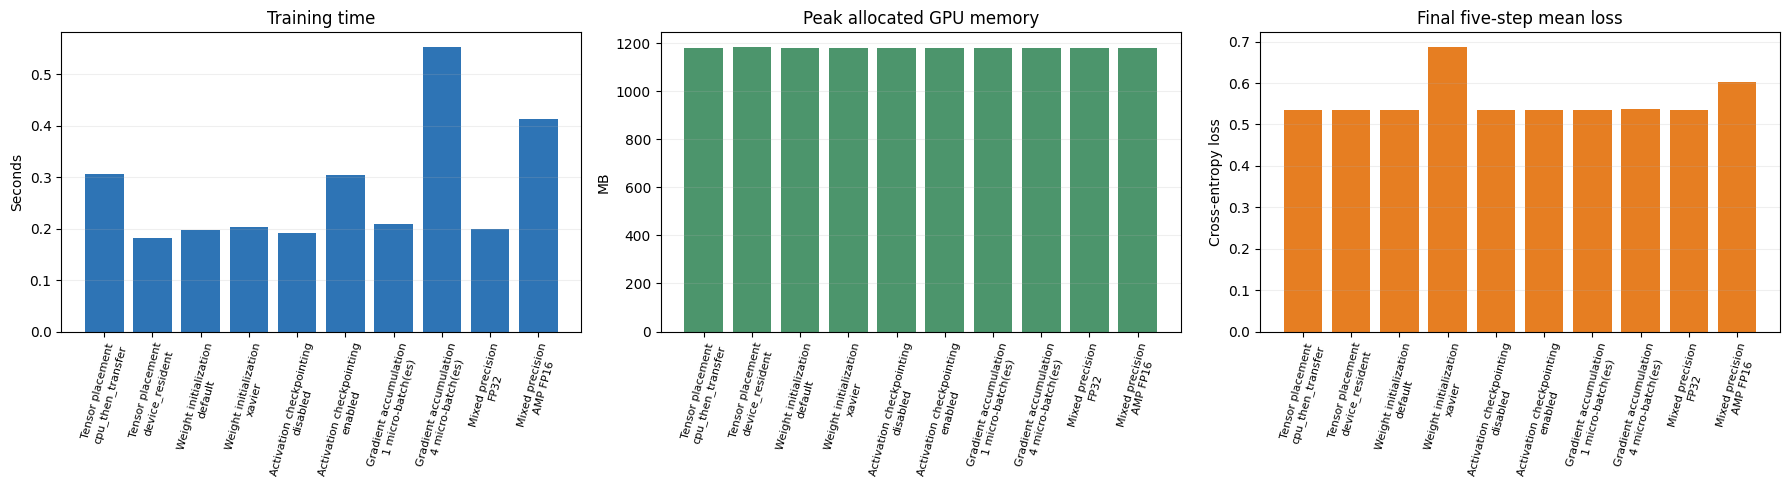

[2026-09-08T10:25:18.022431+00:00] Completed all five optimization comparisons; saved=hw2_outputs/optimization_comparison.png
STEP 24: PASS


In [25]:
# STEP 24: 3.7 Combined measurements and plots
print("STARTING STEP 24: 3.7 Combined measurements and plots")
optimization_results = pd.concat([
    tensor_results,
    initialization_results,
    checkpoint_results,
    accumulation_results,
    mixed_precision_results,
], ignore_index=True)
display(optimization_results.style.format({
    "time_sec": "{:.3f}", "peak_gpu_memory_mb": "{:.1f}",
    "final_5_step_mean_loss": "{:.4f}",
}))

plot_df = optimization_results.dropna(subset=["time_sec"]).copy()
plot_df["label"] = plot_df["technique"] + "\n" + plot_df["configuration"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(plot_df["label"], plot_df["time_sec"], color="#2E74B5")
axes[0].set_title("Training time")
axes[0].set_ylabel("Seconds")
axes[1].bar(plot_df["label"], plot_df["peak_gpu_memory_mb"], color="#4C956C")
axes[1].set_title("Peak allocated GPU memory")
axes[1].set_ylabel("MB")
axes[2].bar(plot_df["label"], plot_df["final_5_step_mean_loss"], color="#E67E22")
axes[2].set_title("Final five-step mean loss")
axes[2].set_ylabel("Cross-entropy loss")
for axis in axes:
    axis.tick_params(axis="x", rotation=75, labelsize=8)
    axis.grid(axis="y", alpha=0.2)
fig.tight_layout()
optimization_plot_path = OUTPUT_DIR / "optimization_comparison.png"
fig.savefig(optimization_plot_path, dpi=180, bbox_inches="tight")
plt.show()
log(f"Completed all five optimization comparisons; saved={optimization_plot_path}")

print("STEP 24: PASS")


### 3.8 Final findings from the controlled run

- **Tensor placement:** keeping data device-resident reduced time from **0.306 s to
  0.182 s** (about 40.5% faster) with the same **0.5346** loss. Peak memory increased
  slightly from 1181.0 MB to 1185.9 MB, so this was a speed improvement, not a memory saving.
- **Weight initialization:** the default initialization achieved **0.5346** loss versus
  **0.6879** for Xavier, with nearly identical time and memory. For this short controlled
  run, the default initialization optimized better.
- **Activation checkpointing:** enabling checkpointing increased time from **0.192 s to
  0.305 s**, produced the same **0.5346** loss, and did not reduce measured peak memory
  (1182.0 MB versus 1181.0 MB). The model was too small for activation savings to exceed
  the runtime's baseline allocations.
- **Gradient accumulation:** four micro-batches increased time from **0.209 s to 0.553 s**
  and reduced peak memory only slightly, from 1182.0 MB to 1181.9 MB. Its **0.5361** loss
  was comparable to the one-batch value of **0.5346**.
- **Mixed precision:** AMP FP16 was slower (**0.414 s versus 0.199 s**), used the same
  measured peak memory, and had a higher loss (**0.6029 versus 0.5346**). For this small
  workload, AMP overhead outweighed its potential throughput benefit.

Overall, device-resident tensors produced the clearest speed benefit. Gradient accumulation
gave only a negligible measured memory reduction, while checkpointing and AMP provided no
benefit at this scale. These timing and memory results are specific to this Colab T4 runtime.


In [26]:
# STEP 25: 3.8 Findings generated from this run
print("STARTING STEP 25: 3.8 Findings generated from this run")
def paired_observation(frame, metric, smaller_is_better=True):
    valid = frame.dropna(subset=[metric])
    if len(valid) < 2:
        return "Comparison unavailable in this runtime."
    first, second = valid.iloc[0], valid.iloc[1]
    winner = first if (
        first[metric] < second[metric] if smaller_is_better
        else first[metric] > second[metric]
    ) else second
    return (
        f"{winner['configuration']} had the {'lower' if smaller_is_better else 'higher'} "
        f"{metric.replace('_', ' ')} in this run."
    )

findings = [
    "Tensor placement: " + paired_observation(tensor_results, "time_sec"),
    "Weight initialization: " + paired_observation(initialization_results, "final_5_step_mean_loss"),
    "Activation checkpointing memory: " + paired_observation(checkpoint_results, "peak_gpu_memory_mb"),
    "Gradient accumulation memory: " + paired_observation(accumulation_results, "peak_gpu_memory_mb"),
    "Mixed precision time: " + paired_observation(mixed_precision_results, "time_sec"),
]
for finding in findings:
    print("-", finding)

print(
    "\nInterpret timing as hardware-specific. Activation checkpointing and gradient "
    "accumulation trade additional computation for lower activation or batch memory. "
    "Mixed precision should reduce tensor memory and may improve GPU throughput, while "
    "weight initialization primarily changes optimization behavior rather than memory."
)

print("STEP 25: PASS")


STARTING STEP 25: 3.8 Findings generated from this run
- Tensor placement: device_resident had the lower time sec in this run.
- Weight initialization: default had the lower final 5 step mean loss in this run.
- Activation checkpointing memory: disabled had the lower peak gpu memory mb in this run.
- Gradient accumulation memory: 4 micro-batch(es) had the lower peak gpu memory mb in this run.
- Mixed precision time: FP32 had the lower time sec in this run.

Interpret timing as hardware-specific. Activation checkpointing and gradient accumulation trade additional computation for lower activation or batch memory. Mixed precision should reduce tensor memory and may improve GPU throughput, while weight initialization primarily changes optimization behavior rather than memory.
STEP 25: PASS


---
# 4. Export required artifacts

This final cell writes the measurement tables, execution log, and compact JSON results.
Download these files after the final top-to-bottom run and add them to the repository.


In [27]:
# STEP 26: 4. Export required artifacts
print("STARTING STEP 26: 4. Export required artifacts")
neighbor_comparison.to_csv(OUTPUT_DIR / "word_neighbors_before_after.csv", index=False)
shift_df.to_csv(OUTPUT_DIR / "embedding_vector_shifts.csv", index=False)
retrieval_evaluation.to_csv(OUTPUT_DIR / "retrieval_evaluation.csv", index=False)
chunking_comparison.to_csv(OUTPUT_DIR / "chunking_comparison.csv", index=False)
rag_failures.to_csv(OUTPUT_DIR / "rag_failures.csv", index=False)
optimization_results.to_csv(OUTPUT_DIR / "optimization_results.csv", index=False)

metrics_lines = [
    "# DATA 266 Homework 2 Metrics",
    "",
    f"SID4: {SID4}; SEED: {SEED}",
    "",
    "## Embedding vector shifts",
    "",
    shift_df.to_markdown(index=False, floatfmt=".4f"),
    "",
    "## RAG retrieval evaluation",
    "",
    retrieval_evaluation[[
        "question", "correct_source", "retrieved_in_top_3", "first_relevant_rank"
    ]].to_markdown(index=False),
    "",
    f"Retrieval Success Rate: {retrieval_success_rate:.1%}",
    "",
    "## RAG failures",
    "",
    rag_failures[["question", "failure_type", "rank", "retrieved_title", "diagnosis"]].to_markdown(index=False),
    "",
    "## Optimization measurements",
    "",
    optimization_results.to_markdown(index=False, floatfmt=".4f"),
    "",
]
Path("METRICS.md").write_text("\n".join(metrics_lines), encoding="utf-8")

RUN_LOG_LINES.extend([
    f"Embedding most shifted={most_shifted['word']} cosine={most_shifted['original_vs_finetuned_cosine']:.4f}",
    f"Embedding least shifted={least_shifted['word']} cosine={least_shifted['original_vs_finetuned_cosine']:.4f}",
    f"RAG retrieval success rate={retrieval_success_rate:.1%}",
    "Optimization results:\n" + optimization_results.to_string(index=False),
    f"Completed HW2 at {datetime.now(timezone.utc).isoformat()}",
])
Path("RUN_LOG.txt").write_text("\n".join(RUN_LOG_LINES) + "\n", encoding="utf-8")

summary = {
    "sid4": SID4,
    "seed": SEED,
    "most_shifted_word": most_shifted["word"],
    "least_shifted_word": least_shifted["word"],
    "retrieval_success_rate": retrieval_success_rate,
    "device": str(DEVICE),
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Created METRICS.md and RUN_LOG.txt")
print("Saved detailed files in:", OUTPUT_DIR.resolve())
print("Saved Word2Vec checkpoint in:", MODEL_DIR.resolve())

print("STEP 26: PASS")


STARTING STEP 26: 4. Export required artifacts
Created METRICS.md and RUN_LOG.txt
Saved detailed files in: /content/hw2_outputs
Saved Word2Vec checkpoint in: /content/models
STEP 26: PASS


## 5. Final conclusion

Fine-tuning adapted all five embeddings to IMDB review language: **review** shifted the
most (original-to-fine-tuned cosine **0.6186**) and **plot** shifted the least
(**0.6932**). The RAG system achieved an **80.0% Retrieval Success Rate (4/5)**, with
rank-1 answer evidence for Inception, The Godfather, Titanic, and Parasite. Its main
failures were incomplete Joker evidence ranked first and a misleading Jack Nicholson
chunk ranked second, which caused the incorrect answer; The Godfather response also
omitted the novel title. In the controlled optimization tests, device-resident tensors
were fastest (**0.182 s versus 0.306 s**) with unchanged loss, while four-way gradient
accumulation produced only a negligible memory reduction and comparable loss. Activation
checkpointing and AMP did not improve memory or speed for this small model, and AMP had
higher loss. These execution-time and GPU-memory measurements are specific to the Colab
T4 runtime and should not be treated as universal performance results.
